## Outcome devaluation and habit expression

The goal of this project is to explore the consequences of the interaction between context uncertainty and context-specific action priors in a set of simulation studies, probably supported by experimental analysis. Main idea is that increased contextual uncertainty generally experienced by users can interact with highly precise context-specific action priors to bring about unexplained phenomena in addiction such behaviour expression despite devaluation.

Firstly we look at **outcome devaluation and habit expression**

It is an open question **whether strong action priors can maintain responding even when outcome value decreases, especially when context inference is uncertain**. Here we want to show the boiling frog effect. Slow contextual change favours within context updating rather than inferring new context. So ideally we want to have a drug context with strong action priors and a slowly changing environment. Agent does not infer new context but updates original consumption one leading to maladaptive behaviour despite devaluation.

-	We were talking about something like this during writing Sarah’s 2021 paper. The thought was to change the reward probability slowly during the context so that there is repetition and the agent stays within context. In a reward change simulation, the originally prefered action slowly becomes punishing. So the consumption action no longer **leads to reward** and the nonconsumption action leads to reward instead. In a devaluation simulation the posterior over contexts at t=2 will be driven by the prior over contexts, the policy surprise and the outcome surprise. Or in other words a balance between what context the agent expected to be in, how surprised the agent is by its own action, and how surprised the agent is by the outcome given its goals and that it executed policy one. Last term should vary with reward contingencies and utility.
-	Is it possible to somehow parameterize how certain an agent infers contexts? And for context inference would the precision of the action prior in the ‘use’ context make it more certain that this context is inferred? (this would directly touch the point of interaction between action prior and context - **yes**). Intuitively: because the agent is uncertain about what to infer as a context, he goes for the context where at least it knows what to do with certainty (stays in control)
-	SUGGESTION
	- Initialize agent with 2 contexts and 2 posible actions. 
	- First context has a strong action preference for action 1 which it believes is very rewarding (v=0.9). Correspondingly, action 2 is non-rewarding. 
	- Then vary true reward rate as a random walk  with some reward as a random walk with different parameters. Vary utility as a random walk with different parameters. I can either directly initialize action preference 
	- Plot habitual tendency (trial at which abstinence action is executed). 
	- Trial at which context posterior goes  for context 1 drops below 0.5

Maybe first simply do devaluation change after having learned contingencies for context 1 and look if this pushes into context 2. Then look at two learned contexts and whether changing utility will push agent into inferring presence of context 1 again with and without habit.


## Classes

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
# import jsonpickle
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations

  
		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility                                        
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])


		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])


		rew_mess = np.einsum('r,rsc -> sc', self.utility, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context_sarah(self,t,tau, likelihood_policies, posterior_policies, prior_context):
		
		if t>0:
			alphas = self.prior_policies_counts[tau,t]

			posterior_context = (posterior_policies * self.ln(likelihood_policies)).sum(axis=0) \
								- (posterior_policies * self.ln(posterior_policies)).sum(axis=0)\
								+ (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0))\
								+ self.ln(prior_context)                            
		else:
			posterior_context = self.ln(prior_context)

		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		self.posterior_context[tau,t] = posterior_context


		return posterior_context
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[pol_ind,:] += posterior_context
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau+1,t,:,:,k].round(3))


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no


		if training_protocol is None:
			self.training_protocol = np.repeat(np.arange(self.number_reward_regimes),\
											   np.ceil(self.TAU/self.number_reward_regimes))[:self.TAU]
		else:
			self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state):
		regime = self.training_protocol[tau]
		self.rewards[tau,t] = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		return self.rewards[tau,t]
	

	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():

	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr

	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]

	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			if tau == 21:
				a = 0
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0



## Functions

In [6]:
sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')




def run_simulation(h=1000, training_protocol = [0,0,1,1], TAU=4, rep=1, na=2, nb=2, ns=3, no=3, nr=3, nc=2, T=2, approx_pred_pol = True, approx_pred_rew = True,
				   utility = np.array([0.98,0.01, 0.01]), Rho = None, reward_decay_rate = None, debug=False, context_volatility=0.98):
	
	
	'''           define policies            '''
	npi = na**(T-1)
	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*nb + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(nb+1)]*nb).transpose([1,2,0])
	state_transition_matrix[:,-1,:] = np.eye(nb+1)[:,:-1]
	# print(f"==>> state_transition_matrix:\n {state_transition_matrix[:,:,0]}")
	# print(f"==>> state_transition_matrix:\n {state_transition_matrix[:,:,1]}")

	state_transition_matrix = np.zeros([ns,ns,na])
	for b in range(nb):
		state_transition_matrix[b,:,b] = 1

	# print(f"==>> state_transition_matrix:\n {state_transition_matrix[:,:,0]}")
	# print(f"==>> state_transition_matrix:\n {state_transition_matrix[:,:,1]}")


	'''          define p(o_t|s_t)            '''
	
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	# counts_prior_rewards += np.random.uniform(low=0,high=0.5, size = counts_prior_rewards.shape)
	
	bias = 1
	init_counts = np.ones([nr,nb+1])
	init_counts[0,0] = bias
	init_counts[1,1:] = bias
	init_counts[:,-1] = [1,1,100]
	counts_prior_rewards[:,:,0] = init_counts


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.9] + [1-0.9]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	if Rho is None:
		p = 0.9
		q = 1-p
		bandits = np.arange(nb)
		Rho = np.ones([nr,ns,len(bandits)])*q

		for context,b in enumerate(bandits):
			Rho[0,b,context] = p
			Rho[1,np.arange(nb+1) != b,context] = p

		Rho[-1,:] = 0
		Rho[:,-1] = 0
		Rho[-1,-1] = 1

		Rho = Rho[:,:,training_protocol]
		
	# Plot task setup

	'''Plot state transition matrix'''
	if False:
	
		fig,axes = plt.subplots(1,2,figsize=(10,4))

		for ai, ax,title in zip([0,1], axes, ['$a_1$ = L1', '$a_2$ = L2']):
			ax.xaxis.tick_top()
			sns.heatmap(state_transition_matrix[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False);
			ax.set_yticklabels(['L1','L2','M'])
			ax.set_title(title);

		'''Plot likelihood matrix'''
	
		fig, ax = plt.subplots()
		ax = sns.heatmap(prior_rewards[...,0],cbar=False,annot=True)
		ax.set_xticklabels(['L1','L2','M'],minor=False)
		ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
		ax.set_title('Reward generation beliefs')


		'''Plot Environment reward generation matrix'''

		fig,axes = plt.subplots(1,2,figsize=(10,4))
		sns.heatmap(Rho[:,:,0],annot=True,ax=axes[0], cbar=False)
		sns.heatmap(Rho[:,:,-1],annot=True,ax=axes[1], cbar=False)
		for ai, ax,title in zip([0,1], axes, ['Reward Regime 1', 'Reward Regime 2']):
			ax.xaxis.tick_top()
			ax.set_xticklabels(['L1','L2','M'],minor=False)
			ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
			ax.set_title(title)


	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = nb,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=no)

	agent = Agent(
			state_transition_matrix,
			utility,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix
			)

	world = World(agent, env)

	world.simulate_experiment()

	return world 


def run_belief_update(actions = None, rewards=None, observations=None, h=1000, training_protocol = [0,0,1,1], TAU=4, rep=1, na=2, nb=2, ns=3, no=3, nr=3, nc=2, T=2, approx_pred_pol = True, approx_pred_rew = True,
				   utility = np.array([0.98,0.01, 0.01]), Rho = None, reward_decay_rate = None, debug=False, context_volatility=0.98):
	
	"""
	Function runs belief updates given some generated rewards, observations and behaviour
	
	"""

	
	'''           define policies            '''
	npi = na**(T-1)
	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*nb + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(nb+1)]*nb).transpose([1,2,0])
	state_transition_matrix[:,-1,:] = np.eye(nb+1)[:,:-1]

	print(state_transition_matrix[:,:,0])
	print(state_transition_matrix[:,:,1])
	
	'''          define p(o_t|s_t)            '''
	
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.5, size = counts_prior_rewards.shape)
	
	bias = 1
	init_counts = np.ones([nr,nb+1])
	init_counts[0,0] = bias
	init_counts[1,1:] = bias
	init_counts[:,-1] = [1,1,100]
	counts_prior_rewards[:,:,0] = init_counts

	# if approx_pred_rew:
	# 	prior_rewards = scp.digamma(counts_prior_rewards) - scp.digamma(counts_prior_rewards.sum(axis=0)) 
	# 	prior_rewards = scp.softmax(prior_rewards, axis=0)
	# else:
	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h

	# if approx_pred_pol:
	# 	prior_policies = scp.softmax(scp.digamma(counts_prior_policies) - scp.digamma(counts_prior_policies.sum(axis=0)))
	# else:
	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.9] + [1-0.9]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	if Rho is None:
		p = 0.9
		q = 1-p
		bandits = np.arange(nb)
		Rho = np.ones([nr,ns,len(bandits)])*q

		for context,b in enumerate(bandits):
			Rho[0,b,context] = p
			Rho[1,np.arange(nb+1) != b,context] = p

		Rho[-1,:] = 0
		Rho[:,-1] = 0
		Rho[-1,-1] = 1

	Rho = Rho[:,:,training_protocol]
	# Plot task setup

	'''Plot state transition matrix'''
	if False:
	
		fig,axes = plt.subplots(1,2,figsize=(10,4))

		for ai, ax,title in zip([0,1], axes, ['$a_1$ = L1', '$a_2$ = L2']):
			ax.xaxis.tick_top()
			sns.heatmap(state_transition_matrix[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False);
			ax.set_yticklabels(['L1','L2','M'])
			ax.set_title(title);

		'''Plot likelihood matrix'''
	
		fig, ax = plt.subplots()
		ax = sns.heatmap(prior_rewards[...,0],cbar=False,annot=True)
		ax.set_xticklabels(['L1','L2','M'],minor=False)
		ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
		ax.set_title('Reward generation beliefs')


		'''Plot Environment reward generation matrix'''

		fig,axes = plt.subplots(1,2,figsize=(10,4))
		for ai, ax,title in zip([0,1], axes, ['Reward Regime 1', 'Reward Regime 2']):
			ax.xaxis.tick_top()
			sns.heatmap(Rho[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False)
			ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
			ax.set_title(title)


	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = nb,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=no)

	agent = Agent(
			state_transition_matrix,
			utility,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix
			)

	world = World(agent, env)

	world.simulate_belief_update(actions, rewards, observations)

	return world 


def run_degradation_simulations(hs=np.array([1,10,1000]), context_volatility=0.99, utility=np.array([0.025,0.9,0.025]),k_range=np.array([0.007, 0.02, 3]), switch=10,\
								na=2, nr=3, nc=2, nsims=5, train_trials=0, TAU=20, T=2, debug=False, sim_name=None):


	nb = na
	ns = nb + 1
	no = ns
	npi = na**(T-1)


	"""agent params"""
	# hs = np.array(hs)
	utilities = np.array([utility])
	agent_instance = np.arange(nsims)
	context_volatilities = np.array([context_volatility])

	"""environment params"""

	# create training protocol
	training_protocol = [np.array([0]*(switch+train_trials) + [1]*switch)]
	
	
	# create training regimes
	start = 0.9
	stop = 0.1
	logistic = lambda x, k: stop - (0.8) / (np.exp(switch*k) - 1) + (np.exp(switch*k) + 1) / (np.exp(switch*k) - 1)*(start-stop)/(1+np.exp(k*(x-switch)))

	Rhos = []
	for k in k_range:
		x = np.arange(0,switch*2,1)
		p_win = logistic(x,k)
		a = np.array([[1-p_win, p_win, np.array([0]*switch*2)],\
					[p_win, 1-p_win, np.array([0]*switch*2)],\
					[np.array([0]*switch*2), np.array([0]*switch*2), np.array([1]*switch*2)]])
		
		Rho = np.zeros([nr,ns,TAU])
		Rho[:,:,train_trials:] = a
		Rho[:,:,:train_trials] = Rho[:,:,train_trials][:,:,None] 
		
		Rhos.append([Rho,k])

	## construct list of simulations
	parameter_combinations = product(agent_instance, hs, utilities, training_protocol, context_volatilities, Rhos)
	sim_params = []



	for p in parameter_combinations:
		# sim specific params
		pars = {}
		pars["rep"] = p[0]
		pars["h"] = p[1]
		pars["utility"] = p[2]
		pars["training_protocol"] = p[3]
		pars["context_volatility"] = p[4]
		pars["Rho"] = p[5][0]

		## global params
		pars["TAU"] = TAU
		pars["na"] = na
		pars["nb"] =  nb
		pars["ns"] = ns
		pars["no"] = no
		pars["nr"] =  nr
		pars["nc"] = nc
		pars["T"] = T
		pars["debug"] = debug
		pars["reward_decay_rate"] = p[5][1]
		pars["train_trials"] = train_trials
		sim_params.append(pars)



	### run simulations
	print(f"simulations to run: {len(sim_params)}")

	df = { col : [] for col in ["run","habitual_tendency",\
								"utility_0"	,"utility_1","utility_2", "context_volatility",\
								"context_a","context_b","context_c","context_d", "context_func",\
								"policy_a","policy_b","policy_c","policy_d","policy_func",\
								"reward_decay_rate","c1_habit","q_context", "dkl_c1", "dkl_c2",\
								"se_context_a", "se_context_b", "se_context_c", "se_context_d","q_policy","train_trials",\
								"habit_c1", "habit_c2", "preference_a2_c1", "preference_a2_c2"]}#,"threshold_c",, "inflection_trial"]} #, "habit_strength_context", "habit_strength_action"
	long_dfs = []
	for pi, p in enumerate(sim_params):
		if pi% 250 == 0:
			print(f"just finished sim {pi}")
		
		train_trials = p.pop("train_trials")
		world = run_simulation(**p)
		agent = world.agent
		
		# Create long format dataframe
		run_arr = np.full(TAU * T, p["rep"])
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		reward_arr = world.environment.rewards.flatten()
		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, p["h"])
		context_volatility_arr = np.full(TAU * T, p["context_volatility"])
		reward_decay_rate_arr = np.full(TAU * T, p["reward_decay_rate"])
		current_reward_rate = world.environment.Rho[1,0,:].repeat(T)
		utility_0_arr = np.full(TAU * T, p["utility"][0])
		utility_1_arr = np.full(TAU * T, p["utility"][1])
		utility_2_arr = np.full(TAU * T, p["utility"][2])
		sim_arr = np.full(TAU*T,pi)
		true_context = np.array(training_protocol).repeat(2)

		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		ourcome_surpr_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			ourcome_surpr_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(npi):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"reward_decay_rate": reward_decay_rate_arr,
			"utility_0": utility_0_arr,
			"utility_1": utility_1_arr,
			"utility_2": utility_2_arr,
			"sim":sim_arr,
			"true_context":true_context,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**ourcome_surpr_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		long_df = pd.DataFrame(long_df_dict)
		long_dfs.append(long_df)



		### calculate H
		sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
		exponential = lambda t, b, c, d: d + np.exp(b*(t-c))
		
		fitting_functions = [sigmoid, exponential]
		t = np.arange(1,TAU+1)

		q_context = agent.posterior_context[:,1,1]
		q_action =  np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0])[:,1]
		

		try:
			context_params, context_pcov = curve_fit(sigmoid, t, q_context, p0=[1.,1.,switch,0.])#, sigma=[0.5]*200)#*40+[2]*100+[0.5]*50)
			context_func = 0.


		except RuntimeError:

			try:
				context_pcov = np.eye(4)
				context_params = np.zeros(4)
				context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
				context_params[0] = 1
				context_func = 1

			except RuntimeError:
				context_params[:] = np.nan
				context_func = np.nan

		try:
			# posterior_pol = (w.agent.posterior_policies[:,0,1]*w.agent.posterior_context[:,0]).sum(axis=1)[10:]
			# plt.figure()
			# plt.ylim((0,1))


			policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
			policy_func = 0

		except RuntimeError:

			try:
				policy_params = np.zeros(4)
				policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
				policy_params[0] = 1.
				policy_func = 1


			except RuntimeError:
				policy_params[:] = np.nan
				policy_func = np.nan

		
		"""Short format dataframe"""

		se = np.sqrt(np.diag(context_pcov))
		q_rewards = agent.prior_rewards[-1,-1]
		p_rewards = world.environment.Rho[:,:,[0,-1]]+1e-10

		dkl = (q_rewards * np.log(q_rewards/p_rewards)).sum(axis=0).mean(axis=0)
		preference_action = long_df.query("t==1").groupby(by="true_context")["observation"].sum() / (TAU // 2)
		
		df["preference_a2_c1"].append(preference_action.iloc[0])
		df["preference_a2_c2"].append(preference_action.iloc[1])
		df["habit_c1"].append(np.argmax(agent.prior_policies[-1,-1], axis=0)[0])
		df["habit_c2"].append(np.argmax(agent.prior_policies[-1,-1], axis=0)[1])
		df["run"].append(p["rep"])
		df["habitual_tendency"].append(1/p["h"])
		df["reward_decay_rate"].append(p["reward_decay_rate"])
		df["context_a"].append(context_params[0])
		df["context_b"].append(context_params[1])
		df["context_c"].append(context_params[2] - TAU // 2)
		df["context_d"].append(context_params[3])
		df["context_func"].append(context_func)
		df["policy_a"].append(policy_params[0])
		df["policy_b"].append(policy_params[1])
		df["policy_c"].append(policy_params[2] - TAU // 2)
		df["policy_d"].append(policy_params[3])
		df["policy_func"].append(policy_func)

		df["c1_habit"].append(np.argmax(agent.prior_policies[-1,-1,:,0]))
		df["q_context"].append(q_context)
		df["dkl_c1"].append(dkl[0])
		df["dkl_c2"].append(dkl[1])
		df["se_context_a"].append(se[0])
		df["se_context_b"].append(se[1])
		df["se_context_c"].append(se[2])
		df["se_context_d"].append(se[3])
		df["q_policy"].append(q_action)
		df["train_trials"].append(train_trials)
		df["utility_0"] = p["utility"][0]
		df["utility_1"] = p["utility"][1]
		df["utility_2"] = p["utility"][2]
		df["context_volatility"].append(p["context_volatility"])

		### plot context  
		# if True:
		# 	fig, axes = plt.subplots(1,3, figsize=(12,3), dpi=dpi)
			# post_context = agent.posterior_context

		# 	axes[0].set_ylim((0,1.05))
		# 	plt.grid(axis="x", alpha=0.7)

		# 	axes[0].xaxis.set_major_locator(MultipleLocator(switch))  # Set tick spacing on x-axis to 1
		# 	# print(agent.actions[:,0].size, np.arange(TAU).size)
		# 	for c in range(nc):
		# 		axes[0].plot(post_context[1,c],label=f"Context {c+1}", linewidth=2)
		# 	axes[1].scatter(np.arange(TAU), agent.actions[:,0],marker="d", s=4)	         
		# 	axes[1].vlines(ymin=0, ymax=1, x=switch)
		# 	fig.suptitle(f"h: {p['h']}, nu: {p['reward_decay_rate']}, habit:{df['c1_habit'][-1]}")

		# 	axes[2].plot(np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0]))
		# 	axes[2].set_ylim((0,1))
		# 	axes[2].plot(np.einsum("tpc,tc -> tp ", agent.likelihood_policies[:,0,:,:], agent.posterior_context[:,1]))

	if sim_name is not None:
		name=sim_name

	df = pd.DataFrame(df)
	print(utility, context_volatility)
	name = f"data_degradation_{TAU}_util{utilities[0][1]}_context{context_volatilities[0]}"
	df.to_csv(name +".csv", index=False)

	long_df = pd.concat(long_dfs)
	long_df.to_csv(name + "_long.csv", index=False)
	print(name)

	return df, long_df, name


def save_excluded(df):
	for ri, row in df.iterrows():
		if row["excluded"]:
			# fitting_functions = [sigmoid, exponential]
			fig, axes = plt.subplots(1,2,figsize=(10,4), sharey=True)
			for fi,fitted_posterior in enumerate(["context","policy"]):
				pars = [fitted_posterior+par for par in ["_a", "_b", "_c", "_d"]]
				q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
				axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
				axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
				axes[fi].set_ylim((0,1.05))
				axes[fi].grid()
				try:
					func_ind = (int(row[f"{fitted_posterior}_func"]))
					x = np.arange(TAU+1)
					axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
					par_vals = row[pars].copy()
					par_vals[2] += TAU // 2
					y = fitting_functions[func_ind](np.arange(TAU+1), *par_vals[pars[func_ind:]])
					axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
					axes[fi].legend(loc="center left")
					axes[fi].set_title(row[pars].round(2).to_numpy())
				except:
					pass
				# fig.savefig(f"img//context_volatility{context_volatility}_rew{row["reward_decay_rate"]}_h{row["habitual_tendency"]}_ind{ri}.png")
				plt.close()


def save_missed_failures(df):
	for ri, row in df.iterrows():
		if not row["excluded"]:
			fitting_functions = [sigmoid, exponential]
			fig, axes = plt.subplots(1,2,figsize=(10,4), sharey=True)
			for fi,fitted_posterior in enumerate(["context","policy"]):
				pars = [fitted_posterior+par for par in ["_a", "_b", "_c", "_d"]]
				q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
				axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
				axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
				axes[fi].set_ylim((0,1.05))
				axes[fi].grid()
				try:
					func_ind = (int(row[f"{fitted_posterior}_func"]))
					x = np.arange(TAU+1)
					axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
					par_vals = row[pars].copy()
					par_vals[2] += TAU // 2
					y = fitting_functions[func_ind](np.arange(TAU+1), *par_vals[pars[func_ind:]])
					axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
					axes[fi].legend(loc="center left")
					axes[fi].set_title(row[pars].round(2).to_numpy())
				except:
					pass
				# fig.savefig(f"img//missed_context_volatility{context_volatility}_rew{row["reward_decay_rate"]}_h{row["habitual_tendency"]}_ind{ri}.png")
				plt.close()


def plot_posterior(df):
	for ri, row in df.iterrows():

		# fitting_functions = [sigmoid, exponential]
		fig, axes = plt.subplots(1,2,figsize=(8,3), sharey=True)
		for fi,fitted_posterior in enumerate(["context","policy"]):
			pars = [fitted_posterior+par for par in ["_a", "_b", "_c", "_d"]]
			q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
			axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
			axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
			axes[fi].set_ylim((0,1.05))
			try:
				func_ind = (int(row[f"{fitted_posterior}_func"]))
				x = np.arange(TAU+1)
				axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
				par_vals = row[pars].copy()
				par_vals[2] += TAU // 2
				y = fitting_functions[func_ind](np.arange(TAU+1), *par_vals[pars[func_ind:]])
				axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
				axes[fi].legend(loc="center left")
				axes[fi].set_title(row[pars].round(2).to_numpy())
			except:
				pass
            
			axes[0].set_ylabel("Posterior context 2")
			axes[1].set_ylabel("Posterior policy 2")


def plot_context_terms(df_agent, context_c=0, policy_c = 0):
	### explore agent behaviour
	df_agent["true_context"]  = np.arange(TAU).repeat(2) >= switch
	df_agent["outcome_surprise_diff"] = df_agent["outcome_surprise_c0"] - df_agent["outcome_surprise_c1"]
	df_agent["policy_surprise_diff"] = df_agent["policy_surprise_c0"] - df_agent["policy_surprise_c1"] 
	df_agent["context_prior_diff"] = np.log(df_agent["posterior_context_c0"]) - np.log(df_agent["posterior_context_c1"]) 
	df_agent["context_post_diff"] = df_agent["posterior_context_c0"] - df_agent["posterior_context_c1"] 


	# ### Context terms plot
	df_agent["action"]  = df_agent["observation"]
	# print(f'==>> df_agent[df_agent["t" == 1]]["action"].to_numpy(): {df_agent[df_agent["t"] == 1]["action"].to_numpy()}')
	df_agent["action"] = df_agent[df_agent["t"] == 1]["action"].to_numpy().repeat(2)

	fig, axes = plt.subplots(1,4, figsize=(15,3))
	
	for ax in axes:
		ax.vlines(context_c, ymin=-10, ymax=6,color="gray")
		ax.vlines(policy_c, ymin=-10, ymax=6,color="gray", linestyle="--")

		# ax.grid()
		ax.set_ylim([-10,6])
	
	sns.scatterplot(ax = axes[0], x="tau", data = df_agent.query("t==1"),y = "outcome_surprise_diff" , hue="action", style="reward", s=20)
	sns.scatterplot(ax = axes[1], x="tau", data = df_agent.query("t==1"),y = "policy_surprise_diff" , hue="action", style="reward", s=20)
	sns.scatterplot(ax = axes[2], x="tau", data = df_agent.query("t==1"),y = "context_prior_diff" , hue="action", style="reward", s=20)
	sns.scatterplot(ax = axes[3], x="tau", data = df_agent.query("t==1"),y = "context_post_diff" , hue="action", style="reward", s=20)

	axes[-1].set_ylim([-1.2,1.2])
	plt.suptitle("Higher difference means higher relative probability for training context")


def plot_policy_likelihood(df_agent):

	### Policy Goal Driven Values
	fig,axes =plt.subplots(1,2, figsize=(6,3))
	plt.tight_layout()
	plt.subplots_adjust(hspace=0.5)

	for c in range(2):
		axes[c].grid()
		axes[c].set_ylim([0,1])
		for pi in range(2):
			sns.lineplot(ax=axes[c], data=df_agent.query("t==0"), x="tau",y=f"likelihood_pi{pi}_c{c}")
	fig.suptitle("Goal driven value of policy $L(\pi|c)$",y=1.05)


def plot_action_selection(df_agent, context_c=0, policy_c = 0):
		df_agent["precision_prior_c0"] = 1/(df_agent["prior_pi0_c0"]*(1-df_agent["prior_pi0_c0"]))
		df_agent["precision_prior_c1"] = 1/(df_agent["prior_pi0_c1"]*(1-df_agent["prior_pi0_c1"]))
		df_agent["precision_like_c0"] = 1/(df_agent["likelihood_pi0_c0"]*(1-df_agent["likelihood_pi0_c0"]))
		df_agent["precision_like_c1"] = 1/(df_agent["likelihood_pi0_c1"]*(1-df_agent["likelihood_pi0_c1"]))
		df_agent["precision_context"] = 1/(df_agent["posterior_context_c0"]*df_agent["posterior_context_c1"])
		h = df_agent.h.unique()[0]
		fig, axes = plt.subplots(1,3,figsize=(10,3))
		fig.tight_layout()
		sns.barplot(ax=axes[0], data=df_agent.query("t == 0"), x="true_context", y="action")
		axes[0].set_ylim((0,1))
		axes[0].set_ylabel("true context")
		axes[0].set_xlabel(f"Prevalence of degraded action, h: {h}")

		### Policy Prior
		# plt.figure()
		sns.heatmap(ax=axes[1], data=df_agent.query("t==1")[["prior_pi0_c0", "prior_pi0_c1"]].reset_index(drop=True), vmax=1, vmin=0)
		# axes[1].set_yticklabels(np.arange(0,TAU,np.ceil(TAU/29)))
		axes[1].set_ylabel("trial")

		### Policy Precision

		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_prior_c0", label="prior pol precision c0",color="blue")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_prior_c1", label="prior pol precision c1", color="orange")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_like_c0", label="like pol precision c0", color="blue", linestyle="--")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_like_c1", label="like pol precision c1", color="orange", linestyle="--")
		axes[2].grid()# sns.scatterplot(ax=axes[2], data=df_agent.query('t==1'),x="tau",y="precision_context", label="context precision", color="black")
		axes[2].vlines(context_c, ymin=axes[2].get_ylim()[0], ymax=axes[2].get_ylim()[1], color="gray")
		axes[2].vlines(policy_c, ymin=axes[2].get_ylim()[0], ymax=axes[2].get_ylim()[1],color="gray", linestyle="--")


def plot_dkl_policy_posterior(df_agent, context_c=0, policy_c = 0):
		
		post_pol = df_agent[[f"posterior_pi{p}" for p in range(2)]].to_numpy()

		for di, dist_name in enumerate(["posterior_", "likelihood_", "prior_"]):
				for c in range(2):
					dist = df_agent[[dist_name+f"pi{p}_c{c}" for p in range(2)]].to_numpy()
					df_agent["dkl_"+ dist_name+f"c{c}"] = (post_pol*np.log(post_pol/dist)).sum(axis=1)
					

		fig, axes = plt.subplots(2,3, figsize=(10,3))
		plt.tight_layout()
		for c in range(2):
			for di, dist_name in enumerate(["posterior_", "likelihood_", "prior_"]):
				# axes[c,di].grid()
				axes[c,di].set_ylim([0,4])
				axes[c,di].vlines(context_c, ymin=0, ymax=4, color="gray")
				axes[c,di].vlines(policy_c, ymin=0, ymax=4,color="gray", linestyle="--")
				sns.scatterplot(ax = axes[c,di], x="tau", data = df_agent.query("t==0"), y = "dkl_"+ dist_name+f"c{c}" , hue="action", s=20)

		fig.suptitle("DKL between posterior over policies and context-specific policy posterior/likelihood/prior",y=1.03)


def plot_reward_distribution(df_agent):
		### Rewards plot
		fig, axes = plt.subplots(2,1,figsize=(12,4))
		plt.tight_layout()
		t100 = []
		t200 = []
		for ai, ax in enumerate(axes):
			sns.heatmap(ax=ax, data=df_agent.query(f"t==1")[[f"reward_s0_c{ai}", f"reward_s1_c{ai}"]].reset_index(drop=True).transpose(), vmax=1, vmin=0)
			t100 += df_agent.query(f"t==1 & tau=={switch}")[[f"reward_s0_c{ai}", f"reward_s1_c{ai}"]].values.round(2).tolist()
			t200 += df_agent.query(f"t==1 & tau=={TAU-1}")[[f"reward_s0_c{ai}", f"reward_s1_c{ai}"]].values.round(2).tolist()
		plt.suptitle(f"at t={TAU//2}: {t100}; at t=TAU: {t200}", y=1.02)
		# sns.heatmap(ax=axes[1], data=df_agent.query(f"t==1 & tau > {TAU//2}")[["reward_s0_c1", "reward_s1_c1"]].reset_index(drop=True), vmax=1, vmin=0)



<>:743: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:743: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_379619/3567785483.py:743: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  fig.suptitle("Goal driven value of policy $L(\pi|c)$",y=1.05)


## Slow contingency change

In these simulation we aim to show that a slow change in reward contingencies can impede the agent's ability to infer context a change in context and lead to expression of habitual behaviour when agent is overhabitual. The idea is that if smoking caused lung cancer tomorrow, no one would smoke.



In the simulations below agents play a two-armed bandit task for TAU trials. 

The rewards associated with each bandit vary smoothly. At trial t=0 bandit 1 brings reward with probabiltiy 0.9 and bandit two brings rewad with probability 0.1. Over successive trials rewards gradually change with bandit 1 becomming less rewarding and bandit 2 more rewarding. At switch trial t=200 switch, the two bandits bring reward with equal  of probability 0.5 and by the end of the simulation at t=TAU, rewards have completely reversed with bandit 1 bringing reward with probability 0.1 and bandit 2 with 0.9.

Simulations are run for a given
- reward change rate k (the lower the k, the slower the rewards change)
- habitual tendency h (the lower the h, the slower a habit is learned)
- utility (agent preferes reward vs no-reward)
- context volatility (how certain agent is he will transition in the same environment)


First we look at simulations where we have a strong, medium and weak habit learner (h=1,0.1,0.01) and compare three different rates of reward change. A sigmoid was fit to the posterior over context 1 and policy 1 for all agents. 

Based on obtained fitting curves agents where:

- posterior over contexts oscilates between two contexts
- a context switch is never inferred
- the posterior over policies never infers action 2 with probablity > 0.5 and the agent doesn't switches into executing novel action

are treated as not having inferred a context switch.

Below figure shows that the slower rewards change, the longer strong habit learners take to adapt to changing contingencies. Eventually all agents infer a new context. Habitual agents take substantially longer to do so and are prone to habit bleed through, where action learned in context 1 is also habituated in context 2.



### Context volatility = 0.99

#### Run simulations

simulations to run: 600
just finished sim 0


just finished sim 250
just finished sim 500
[0.025 0.95  0.025] 0.99
data_degradation_400_util0.95_context0.99


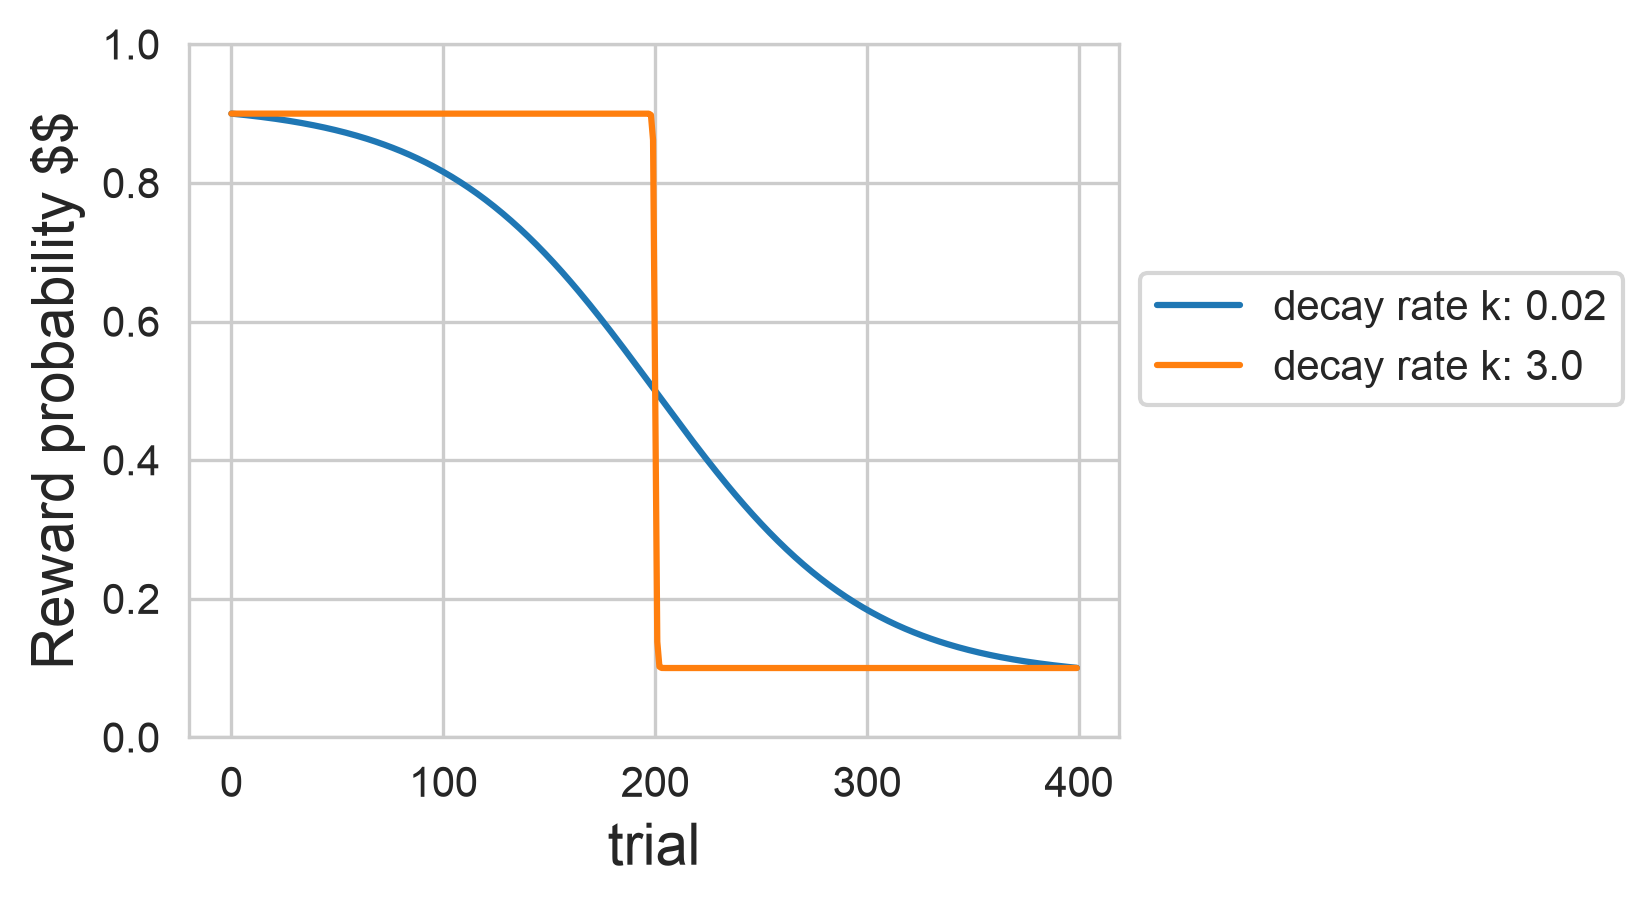

In [37]:
"""Run Some Simulations"""

np.random.seed(1)
TAU = 400
hs = np.array([1, 10, 1000])
utility = np.array([0.025,0.95, 0.025])
context_volatility = 0.99
switch = TAU//2
train_trials = 0
nsims=100
k_range = [0.02, 0.04, 0.1,  3.]
k_range = [0.02, 3.]
# print(np.log10(k_range))
# np.power(10,np.linspace(-2, 0.3, 4))
# print(np.linspace(-4.9,1.1,4))
# k_range = np.exp(np.linspace(-4,1.1,4))
# k_range = np.exp(np.linspace(-4,1.1,4))

def plot_reward_regime(k_range, switch, TAU):
	start = 0.9
	stop = 0.1
	# function that ranges between start and stop decays with a varying rate k
	logistic = lambda x, k: stop - (0.8) / (np.exp(switch*k) - 1) + (np.exp(switch*k) + 1) / (np.exp(switch*k) - 1)*(start-stop)/(1+np.exp(k*(x-switch)))
	plt.figure(figsize=(4,3),dpi=300)
	for k in k_range:
		x = np.arange(0,switch*2,1)
		p_win = logistic(x,k)
		
		plt.plot(np.arange(TAU), p_win, label=f"decay rate k: {k}")
		plt.xlabel("trial", fontsize=14)
		plt.ylabel(r"Reward probability $\$", fontsize=14)
		plt.ylim([0,1])
		plt.legend(bbox_to_anchor=(1,0.7))
		
	# plt.legend()


plot_reward_regime(k_range, switch, TAU)
name = "data_degradation_400_util0.95_context0.99"
df, long_df, name = run_degradation_simulations(TAU=TAU, sim_name=name, hs=hs, utility=utility, context_volatility=context_volatility, switch=switch, k_range=k_range,nsims=nsims)

#### Analyse and plot curve fitting results

Index(['observation', 'action', 'reward', 'context_volatility', 'utility_0',
       'utility_1', 'utility_2', 'sim', 'true_context', 'prior_pi0_c0',
       'prior_pi1_c0', 'prior_pi0_c1', 'prior_pi1_c1', 'likelihood_pi0_c0',
       'likelihood_pi1_c0', 'likelihood_pi0_c1', 'likelihood_pi1_c1',
       'posterior_pi0_c0', 'posterior_pi1_c0', 'posterior_pi0_c1',
       'posterior_pi1_c1', 'posterior_context_c0', 'posterior_context_c1',
       'policy_entropy_c0', 'policy_entropy_c1', 'policy_surprise_c0',
       'policy_surprise_c1', 'outcome_surprise_c0', 'outcome_surprise_c1',
       'posterior_pi0', 'posterior_pi1', 'reward_s0_c0', 'reward_s1_c0',
       'reward_s0_c1', 'reward_s1_c1'],
      dtype='str')


<Axes: xlabel='h', ylabel='proportion'>

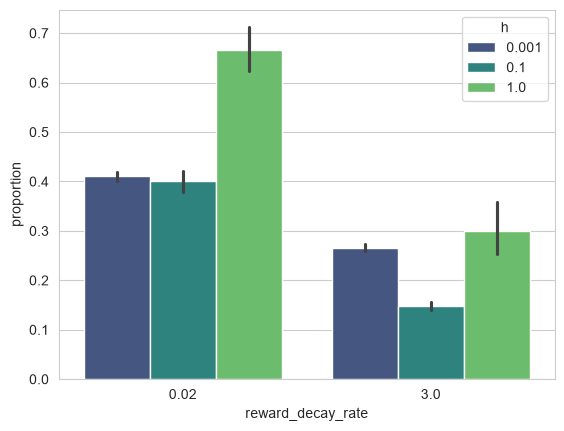

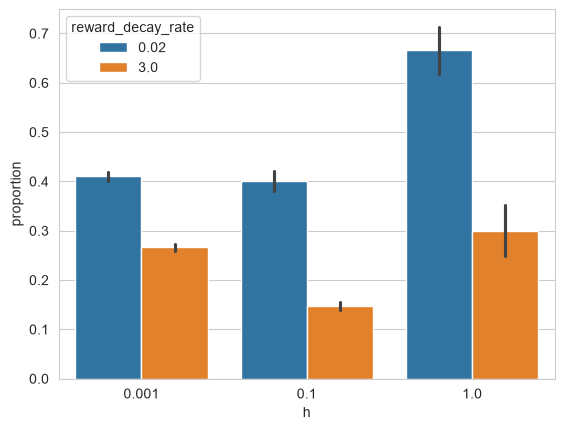

In [ ]:
# df = pd.read_csv("data_degradation_400_util0.95_context0.99.csv")
df_long = pd.read_csv("data_degradation_400_util0.95_context0.99_long.csv")

df_long.columns
df_long["h"] = (1/df_long["h"]).astype("category")
df_long["reward_decay_rate"] = df_long["reward_decay_rate"].astype("category")
df_long["action"] = df_long["action"].astype("category")
ks = df_long.reward_decay_rate.unique()
K = ks.size

plot_df = df_long.set_index(["h","reward_decay_rate","run","tau","t"])

print(plot_df.columns)

"""      Policy posterior        """
# plt.figure(figsize=(16,4))
# for ki, k in enumerate(ks):
# 	# display(plot_df.loc[:,k,:,:,0].reset_index().head())
# 	plt.subplot(1,K,ki+1)
# 	sns.lineplot(data=plot_df.loc[:,k,:,:,0].reset_index(), x = "tau", y="posterior_pi0", hue="h", errorbar="se", palette="viridis")


"""      Context posterior       """
# shows that the slower the change the more uncertain the environment.
# what is my prediction for a slowly varying environment? Weak habit learners are driven purely by goal-directed value of an action.
# They would be less exploitative but infer a context switch faster. 
# They will behave more optimally once context changes


# plt.figure(figsize=(16,4))
# for ki, k in enumerate(ks):
# 	# display(plot_df.loc[:,k,:,:,0].reset_index().head())
# 	plt.subplot(1,K,ki+1)
# 	sns.lineplot(data=plot_df.loc[:,k,:,:,0].reset_index(), x = "tau", y="posterior_context_c0", hue="h", errorbar="se", palette="viridis")


"""reward gathered pre and post optimal action changing"""

# plot_df = df_long.query("t==1").groupby(by=["h","reward_decay_rate","run","true_context"])["reward"].sum()
# plot_df = plot_df.reset_index().query("true_context == 0")
# plt.figure()
# sns.barplot(data=plot_df, x="reward_decay_rate", y="reward", hue="h", palette="viridis")

# plt.figure()
# sns.barplot(data=plot_df, hue="reward_decay_rate", y="reward", x="h", palette="tab10")
# # plot_df.head()

"""Executed action"""

plot_df = df_long.query("t==0").groupby(by=["h","reward_decay_rate","run","true_context"])["action"].value_counts(normalize=True, dropna=False)
plot_df = plot_df.reset_index().query("action==0 & true_context == 1")
plt.figure()
sns.barplot(data=plot_df, x="reward_decay_rate", y="proportion", hue="h", palette="viridis")


In [39]:
df = pd.read_csv("data_degradation_400_util0.95_context0.99.csv")
df_long = pd.read_csv("data_degradation_400_util0.95_context0.99_long.csv")

context_volatility = df.context_volatility.unique()
print("simulation setup")
print(f"habitual tendency:\n{df.habitual_tendency.unique()}")
print(f"reward decay rate:\n{df.reward_decay_rate.unique()}")
# print(f"utility:\n{[float(util) for util in (df.iloc[0][["utility_0","utility_1", "utility_2"]].to_list())]}")
util_list = [float(util) for util in df.iloc[0][["utility_0", "utility_1", "utility_2"]].to_list()]
print(f"utility:\n{util_list}")
print(f"context volatility:\n{context_volatility}")

# df["habitual_tendency"] = np.log10(df["habitual_tendency"]).round(2) # df["habitual_tendency"]#
df["reward_decay_rate"] = np.log(df["reward_decay_rate"]).round(2) # df["reward_decay_rate"]#
df["habitual_tendency"] = df["habitual_tendency"].astype("category")

### clean fitting data


df["excluded"] = False
print((df["excluded"] == True).sum())
df.loc[df["policy_a"] < 0.35, "excluded"] = True   # exclude agents that don't infer second policy with probability higher than 0.35
print((df["excluded"] == True).sum())

df.loc[df["context_a"] < 0.35, "excluded"] = True  # exclude agents that don't infer second context with probability higher than 0,35
print((df["excluded"] == True).sum())

df.loc[df["context_c"].isna(),  "excluded"] = True # exclude all agents where no sigmoid could be fitted at all
print((df["excluded"] == True).sum())

df.loc[df["policy_c"].isna(),  "excluded"] = True # exclude all agents where no sigmoid could be fitted at all
print((df["excluded"] == True).sum())

df.loc[df["context_c"] > TAU//2, "excluded"] = True # 
print((df["excluded"] == True).sum())
						   #
df.loc[(df["policy_c"] > 130) & (df["policy_a"] > 0.7) & (df["policy_a"] > 1.01), "excluded"] = True
print((df["excluded"] == True).sum())

df.loc[df["context_c"] < -TAU//4, "excluded"] = True
print((df["excluded"] == True).sum())

df.loc[df["policy_c"] < -TAU//4, "excluded"] = True
print((df["excluded"] == True).sum())

# save_excluded(df.query("habitual_tendency==0"),)
# save_missed_failures(df.query("habitual_tendency==0"))

df.loc[df["excluded"] == True, ["context_c", "policy_c"]] = (TAU//2) + 1


simulation setup
habitual tendency:
[1.    0.1   0.001]
reward decay rate:
[0.02 3.  ]
utility:
[0.025, 0.95, 0.025]
context volatility:
[0.99]
0
25
26
28
40
40
40
41
42


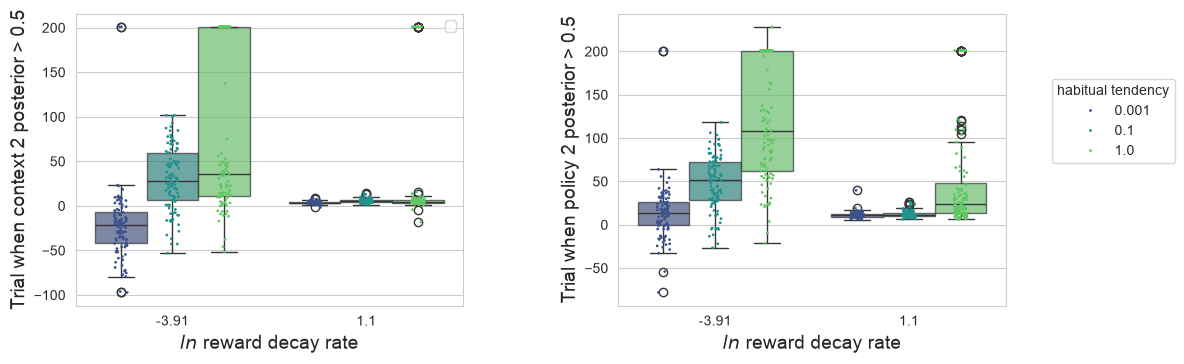

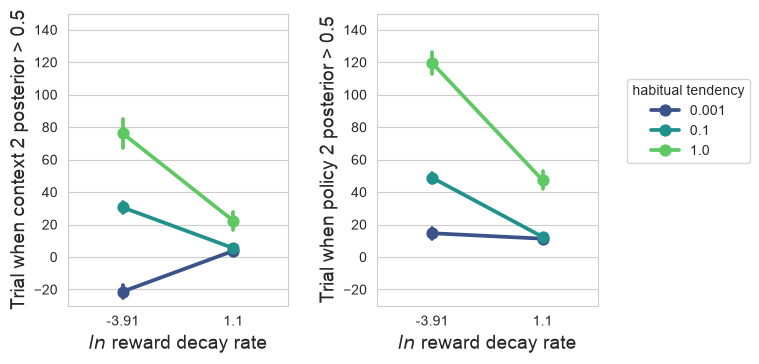

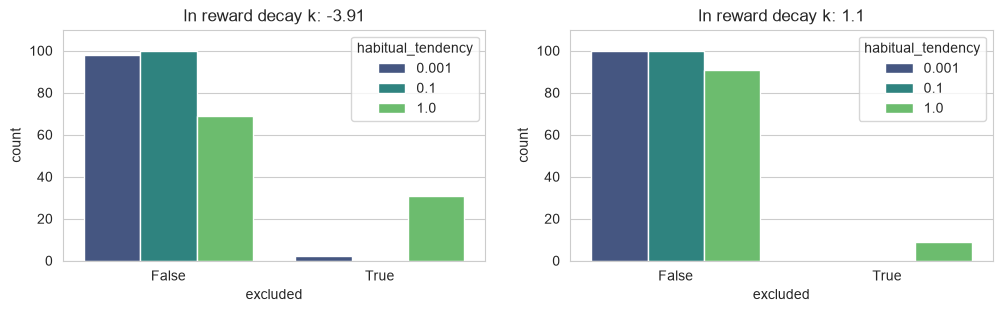

In [40]:


fig, axes = plt.subplots(1,2, figsize=(10,3.5))
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
sns.boxplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", boxprops=dict(alpha=.7), palette="viridis",legend=None)
sns.stripplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", palette="viridis", dodge=True, s=2)
sns.boxplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", boxprops=dict(alpha=.7), palette="viridis",legend=None)
sns.stripplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", palette="viridis", dodge=True, s=2)

axes[0].set_ylabel("Trial when context 2 posterior > 0.5", fontsize=14)
axes[1].set_ylabel("Trial when policy 2 posterior > 0.5", fontsize=14)

axes[0].legend([])
axes[1].legend(bbox_to_anchor=(1.,0.8), title="habitual tendency")


for ax in axes:
	# ax.set_ylim([-30,150])
	ax.set_xlabel(rf"$ln$ reward decay rate", fontsize=14)
axes[1].legend(bbox_to_anchor=(1.1,0.8), title=r"habitual tendency")


fig, axes = plt.subplots(1,2, figsize=(6,3.5))
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
sns.pointplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", marker="o",errorbar="se",palette="viridis",legend=None)
sns.pointplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", marker="o", errorbar="se",palette="viridis")
axes[0].set_ylabel("Trial when context 2 posterior > 0.5", fontsize=14)
axes[1].set_ylabel("Trial when policy 2 posterior > 0.5", fontsize=14)

for ax in axes:
	ax.set_ylim([-30,150])
	ax.set_xlabel(rf"$ln$ reward decay rate", fontsize=14)
axes[1].legend(bbox_to_anchor=(1.1,0.8), title=r"habitual tendency")

df["excluded"] = df["context_c"] == (TAU//2+1)

fig, axes = plt.subplots(1,df["reward_decay_rate"].unique().size, figsize=(12,3))
for ki, k in enumerate(df["reward_decay_rate"].unique()):
	sns.countplot(ax=axes[ki], data=df.query(f"reward_decay_rate == {k}"),x="excluded", hue="habitual_tendency", palette="viridis")

	axes[ki].set_title(f"ln reward decay k: {k}")
	axes[ki].set_ylim([0,110])

In the first two plots we look at the distribution of the inferred inflection point parameters for the posterior over contexts and policies (context_c and policy_c). e inflection point parameter corresponds to the trial at which fitted sigmoid becomes more than 50% of its max values. As explained above, cases where sigmoid could not be fitted or fitted nonsense, the inflection point was set to TAU//2. 

Plots:
1. Violin plot of inferred inflection points for the context and policy posteriors. 
2. Same data, but showing the average inflection point for different habit learneres and different rates of reward decay, similar to the plot in Sarah's paper.
3. Plot of how many inflection points were manually set to TAU//2, corresponding to the number of agents, that failed to acquiere correct contextual structure alltogether.

From these plots can see that overall the quicker rewards decay, the faster agents perceive a change in context, as expected. Additionally, more agents manage to learn correct contextual structure and switch action in response to context change. 

Gradual changes in reward instead lead to more within context adaptation and slower shift to learning a novel context (higher policy_c, context_c and more excluded (failed) agents).

Importantly, **this effect is the most pronounced for strong habit learners (those with log habitual_tendency close to 0)** as hypothesized, with strong habit learners having the most failed agents and the highest inflection points. 

Overall **very few habit learners completely fail to infer presence of a new context**. The reward prediction error drives them to eventually notice that something new has happened. Even so, in practice they either 

1. fail to learn an adequate second context (with reward distributions for that context staying close to uniform).
2. infer the presence of a second context, with the correct contingencies (higher reward rate for action 2 than action 1) but are unable to switch response nonetheless, due to habit bleedthrough. From an SUD perspective, the agent is capable of recognizing that it is in a novel situation where the originally learned drug action is no longer rewarding but the compulsion to consume persists even in this new context.

Below are some examples of such behaviour.



### Context volatility = 0.95

Here I cause increased contextual posterior uncertainty by decreasing context self-transition. In essence, this means that the posterior from which the agent samples an action is flatter since the agent is not sure which context it transitioned into at the end of an episode.  

Many of the planning agents did not succeed in learning the environmental dynamics at the slowest reward decay rate which is not a good comparison point. At slightly higher reward decay rate, I see expected result however, where planners learn appropriately and automatising agents show impeded contextual switching.

simulations to run: 2000
just finished sim 0


KeyboardInterrupt: 

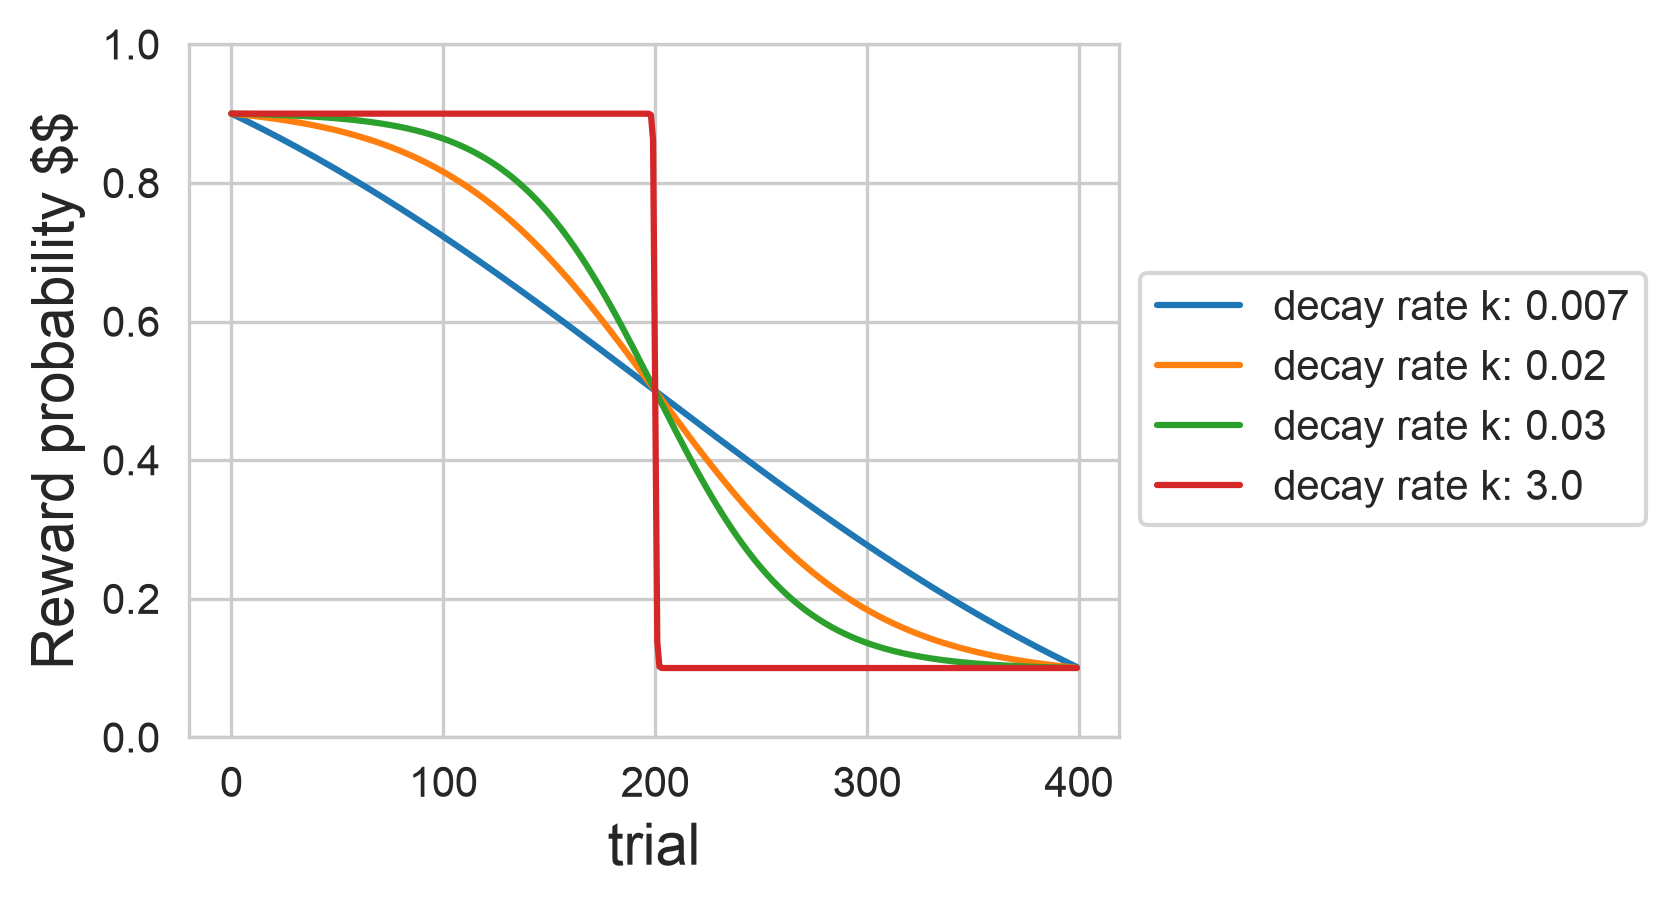

In [20]:
"""Run Some Simulations"""

np.random.seed(7)
TAU = 400
hs = np.array([1, 10, 20, 100, 1000])
utility = np.array([0.025,0.95, 0.025])
context_volatility = 0.95
switch = TAU//2
train_trials = 0
nsims=100
k_range = [0.007, 0.02, 0.03, 3.]
plot_reward_regime(k_range, switch, TAU)
df, long_df, name = run_degradation_simulations(TAU=TAU, hs=hs, utility=utility, context_volatility=context_volatility, switch=switch, k_range=k_range,nsims=nsims)

simulation setup
habitual tendency:
[1.    0.1   0.05  0.01  0.001]
reward decay rate:
[0.007 0.02  0.03  3.   ]
utility:
[0.025, 0.95, 0.025]
context volatility:
[0.95]
0
0
0
78
333
333


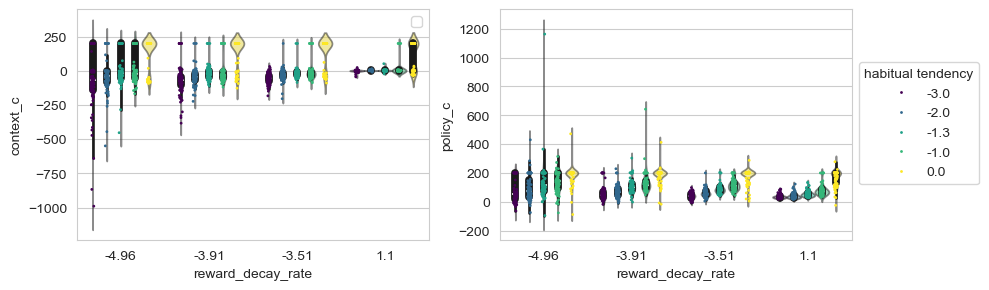

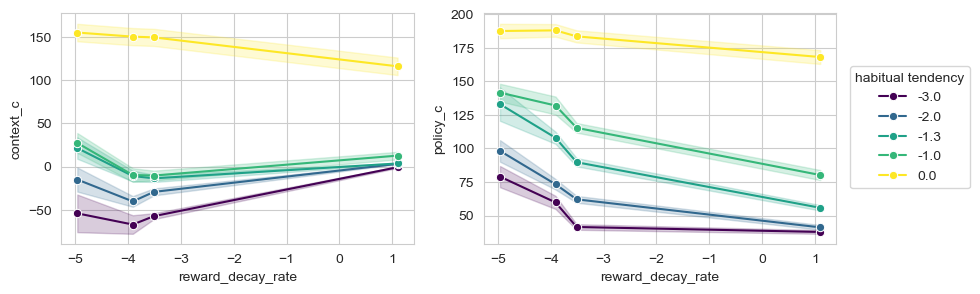

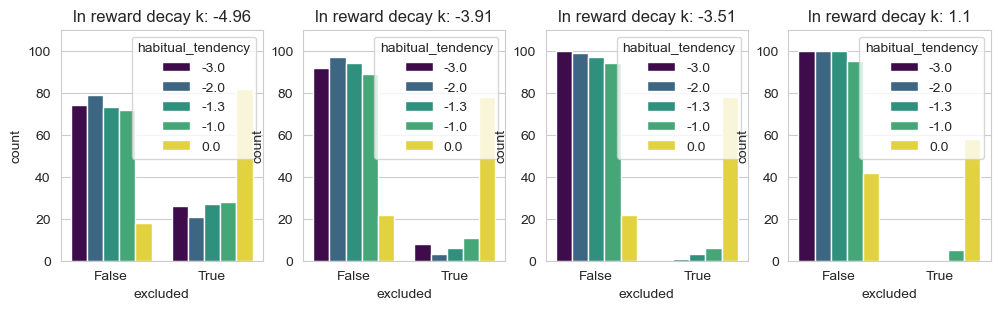

In [ ]:
# df = pd.read_csv("new_data_reward_slow_decay_trials400_context_volatility.csv")
# print(df.columns)
# df_long = pd.read_csv("new_data_reward_slow_decay_trials400_long.csv")

print("simulation setup")
print(f"habitual tendency:\n{df.habitual_tendency.unique()}")
print(f"reward decay rate:\n{df.reward_decay_rate.unique()}")
print(f"utility:\n{[float(util) for util in (df.iloc[0][["utility_0","utility_1", "utility_2"]].to_list())]}")
print(f"context volatility:\n{df.context_volatility.unique()}")

df["habitual_tendency"] = np.log10(df["habitual_tendency"]).round(2) # df["habitual_tendency"]#
df["reward_decay_rate"] = np.log(df["reward_decay_rate"]).round(2) # df["reward_decay_rate"]#



### apply mask
curr = (df["context_c"] == TAU//2+1).sum()
print(curr)
# df.loc[df["policy_a"] < 0.35,["context_c","policy_c"]] = (TAU//2)+1   # exclude agents that don't infer second policy with probability higher than 0.35
print((df["context_c"] == TAU//2+1).sum())

# df.loc[df["context_a"] < 0.35,["context_c","policy_c"]] = (TAU//2)+1  # exclude agents that don't infer second context with probability higher than 0,35
print((df["context_c"] == TAU//2+1).sum())

df.loc[df["context_c"].isna(), ["context_c","policy_c"]] = (TAU//2)+1 # exclude all agents where no sigmoid could be fitted at all
print((df["context_c"] == TAU//2+1).sum())

df.loc[df["policy_c"].isna(), ["context_c","policy_c"]] = (TAU//2)+1 # exclude all agents where no sigmoid could be fitted at all
print((df["context_c"] == TAU//2+1).sum())

# df.loc[df["context_c"] > TAU//2,["context_c","policy_c"]] = (TAU//2)+1 # 
# print((df["context_c"] == TAU//2+1).sum()) 
#                            #
# df.loc[(df["policy_c"] > 130) & (df["policy_a"] > 0.7) & (df["policy_a"] > 1.01),["context_c","policy_c"]] = (TAU//2)+1
print((df["context_c"] == TAU//2+1).sum())

df.loc[(df["context_c"] < -TAU//4) & (df["policy_a"] < 0.25),["context_c","policy_c"]] = (TAU//2)+1
# print((df["context_c"] == TAU//2+1).sum())

df.loc[df["policy_c"] < - 100,["context_c","policy_c"]] = (TAU//2)+1


fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.violinplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", alpha=0.5, palette="viridis",legend=None)
sns.stripplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", palette="viridis", dodge=True, s=2)
sns.violinplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", alpha=0.5, palette="viridis",legend=None)
sns.stripplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", palette="viridis", dodge=True, s=2)
axes[0].legend([])
axes[1].legend(bbox_to_anchor=(1.,0.8), title="habitual tendency")
fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.lineplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", marker="o",errorbar="se",palette="viridis",legend=None)
sns.lineplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", marker="o", errorbar="se",palette="viridis")
# for ax in axes:
	# ax.set_ylim([0,200])

axes[1].legend(bbox_to_anchor=(1.4,0.8), title="habitual tendency")


df["excluded"] = df["context_c"] == (TAU//2+1)
# counts = df.groupby(by=["habitual_tendency","reward_decay_rate"])["excluded"].sum().reset_index()

fig, axes = plt.subplots(1,df["reward_decay_rate"].unique().size, figsize=(12,3))
for ki, k in enumerate(df["reward_decay_rate"].unique()):
	sns.countplot(ax=axes[ki], data=df.query(f"reward_decay_rate == {k}"),x="excluded", hue="habitual_tendency", palette="viridis")
	axes[ki].set_title(f"ln reward decay k: {k}")
	axes[ki].set_ylim([0,110])

### Context Volatility = 0.9

simulations to run: 2000
just finished sim 0


C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\1282754959.py:527: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)


just finished sim 250
just finished sim 500
just finished sim 750
just finished sim 1000


C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\1282754959.py:527: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\1282754959.py:527: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)


just finished sim 1250
just finished sim 1500


C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\1282754959.py:527: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)


just finished sim 1750


C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\1282754959.py:527: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\1282754959.py:527: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)


[0.025 0.95  0.025] 0.9
data_degradation_400_util0.95_context0.9


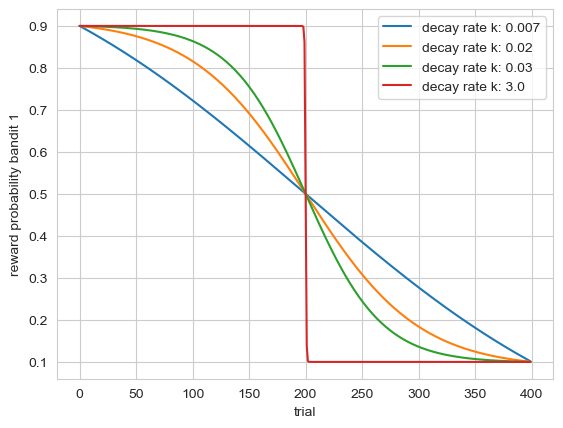

In [ ]:
"""Run Some Simulations"""

np.random.seed(7)
TAU = 400
hs = np.array([1, 10, 20, 100, 1000])
utility = np.array([0.025,0.95, 0.025])
context_volatility = 0.9
switch = TAU//2
train_trials = 0
nsims=100
k_range = [0.007, 0.02, 0.03, 3.]
plot_reward_regime(k_range, switch, TAU)
df, long_df, name = run_degradation_simulations(TAU=TAU, hs=hs, utility=utility, context_volatility=context_volatility, switch=switch, k_range=k_range,nsims=nsims)

simulation setup
habitual tendency:
[1.    0.1   0.05  0.01  0.001]
reward decay rate:
[0.007 0.02  0.03  3.   ]
utility:
[0.025, 0.95, 0.025]
context volatility:
[0.9]
0
0
0
379
759
759


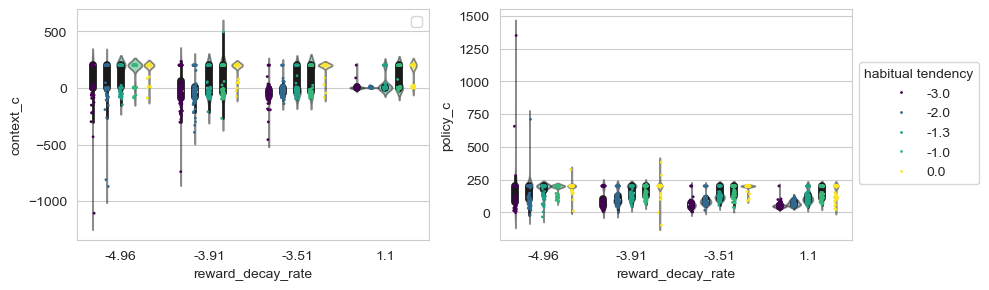

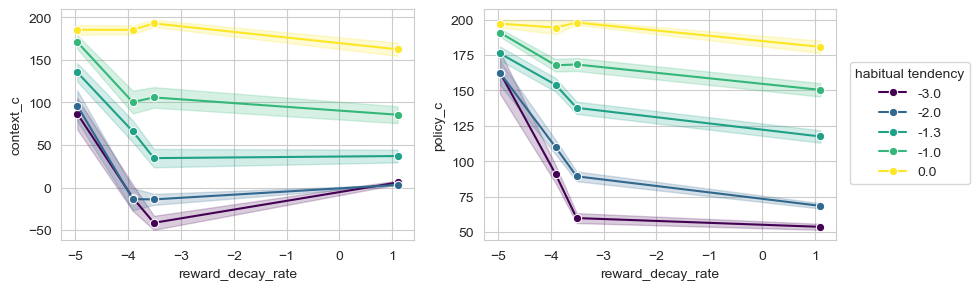

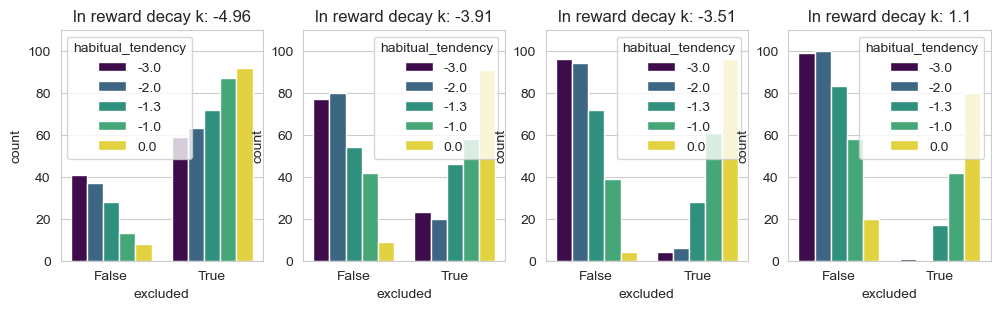

In [ ]:
# df = pd.read_csv("new_data_reward_slow_decay_trials400_context_volatility.csv")
# print(df.columns)
# df_long = pd.read_csv("new_data_reward_slow_decay_trials400_long.csv")

print("simulation setup")
print(f"habitual tendency:\n{df.habitual_tendency.unique()}")
print(f"reward decay rate:\n{df.reward_decay_rate.unique()}")
print(f"utility:\n{[float(util) for util in (df.iloc[0][["utility_0","utility_1", "utility_2"]].to_list())]}")
print(f"context volatility:\n{df.context_volatility.unique()}")

df["habitual_tendency"] = np.log10(df["habitual_tendency"]).round(2) # df["habitual_tendency"]#
df["reward_decay_rate"] = np.log(df["reward_decay_rate"]).round(2) # df["reward_decay_rate"]#



### apply mask
curr = (df["context_c"] == TAU//2+1).sum()
print(curr)
# df.loc[df["policy_a"] < 0.35,["context_c","policy_c"]] = (TAU//2)+1   # exclude agents that don't infer second policy with probability higher than 0.35
print((df["context_c"] == TAU//2+1).sum())

# df.loc[df["context_a"] < 0.35,["context_c","policy_c"]] = (TAU//2)+1  # exclude agents that don't infer second context with probability higher than 0,35
print((df["context_c"] == TAU//2+1).sum())

df.loc[df["context_c"].isna(), ["context_c","policy_c"]] = (TAU//2)+1 # exclude all agents where no sigmoid could be fitted at all
print((df["context_c"] == TAU//2+1).sum())

df.loc[df["policy_c"].isna(), ["context_c","policy_c"]] = (TAU//2)+1 # exclude all agents where no sigmoid could be fitted at all
print((df["context_c"] == TAU//2+1).sum())

# df.loc[df["context_c"] > TAU//2,["context_c","policy_c"]] = (TAU//2)+1 # 
# print((df["context_c"] == TAU//2+1).sum()) 
#                            #
# df.loc[(df["policy_c"] > 130) & (df["policy_a"] > 0.7) & (df["policy_a"] > 1.01),["context_c","policy_c"]] = (TAU//2)+1
print((df["context_c"] == TAU//2+1).sum())

df.loc[(df["context_c"] < -TAU//4) & (df["policy_a"] < 0.25),["context_c","policy_c"]] = (TAU//2)+1
# print((df["context_c"] == TAU//2+1).sum())

df.loc[df["policy_c"] < - 100,["context_c","policy_c"]] = (TAU//2)+1


fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.violinplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", alpha=0.5, palette="viridis",legend=None)
sns.stripplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", palette="viridis", dodge=True, s=2)
sns.violinplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", alpha=0.5, palette="viridis",legend=None)
sns.stripplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", palette="viridis", dodge=True, s=2)
axes[0].legend([])
axes[1].legend(bbox_to_anchor=(1.,0.8), title="habitual tendency")
fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.lineplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", marker="o",errorbar="se",palette="viridis",legend=None)
sns.lineplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", marker="o", errorbar="se",palette="viridis")
# for ax in axes:
	# ax.set_ylim([0,200])

axes[1].legend(bbox_to_anchor=(1.4,0.8), title="habitual tendency")


df["excluded"] = df["context_c"] == (TAU//2+1)
# counts = df.groupby(by=["habitual_tendency","reward_decay_rate"])["excluded"].sum().reset_index()

fig, axes = plt.subplots(1,df["reward_decay_rate"].unique().size, figsize=(12,3))
for ki, k in enumerate(df["reward_decay_rate"].unique()):
	sns.countplot(ax=axes[ki], data=df.query(f"reward_decay_rate == {k}"),x="excluded", hue="habitual_tendency", palette="viridis")
	axes[ki].set_title(f"ln reward decay k: {k}")
	axes[ki].set_ylim([0,110])

<>:48: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:48: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\siahr\AppData\Local\Temp\ipykernel_10592\2631242000.py:48: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  fig.suptitle("Goal driven value of policy $L(\pi|c)$",y=1.05)


## Habit strength as a function of environment stochasticity

Recreate Sarah's experiment


In [ ]:
np.random.seed(7)
plt.rcParams['figure.dpi'] = 100

dpi = 100
debug = False

# global params
na = 2
nb = na
ns = nb + 1
no = ns
nr = 3
nc = 2
T = 2
nsims = 100


"""agent params"""
hs = np.array([1,10,100])
utility = np.array([[0.025, 0.95, 0.025]])
# utility = np.array([[0.495, 0.495, 0.01]])

agent_instance = np.arange(nsims)
context_volatility = np.array([0.99])


"""environment params"""

# create training protocol
switch = 100   # trial at which probability of reward is 50/50
training_protocol = np.array([0]*(switch) + [1]*(switch))
TAU = len(training_protocol)

reward_stochasticity = np.arange(0.05,0.45, 0.05).round(5)#np.array([0.65])#
Rhos = []

for nu in reward_stochasticity:
	print(nu)
	Rho = np.zeros([nr,ns,nc])
	Rho[:,:,0] = np.array([[nu, 1-nu, 0],\
					[1-nu, nu, 0],\
					[0, 0, 1]])
	Rho[:,:,1] = np.array([[1-nu, nu, 0],\
					[nu, 1-nu, 0],\
					[0, 0, 1]])
	Rho = Rho[:,:,training_protocol]
	Rhos.append([Rho,nu])


## construct list of simulations
parameter_combinations = product(agent_instance, hs, utility, [training_protocol], context_volatility, Rhos)
sim_params = []


for p in parameter_combinations:
	# sim specific params
	pars = {}
	pars["rep"] = p[0]
	pars["h"] = p[1]
	pars["utility"] = p[2]
	pars["training_protocol"] = p[3]
	pars["context_volatility"] = p[4]
	pars["Rho"] = p[5][0]

	## global params
	pars["TAU"] = TAU
	pars["na"] = na
	pars["nb"] =  nb
	pars["ns"] = ns
	pars["no"] = no
	pars["nr"] =  nr
	pars["nc"] = nc
	pars["T"] = T
	pars["debug"] = debug
	pars["reward_decay_rate"] = p[5][1]
	sim_params.append(pars)



### run simulations
print(f"simulations to run: {len(sim_params)}")
df = { col : [] for col in ["run","habitual_tendency",\
							"context_a","context_b","context_c","context_d", "context_func",\
							"policy_a","policy_b","policy_c","policy_d","policy_func",\
							"reward_decay_rate","c1_habit","q_context", "dkl_c1", "dkl_c2",\
							"se_context_a", "se_context_b", "se_context_c", "se_context_d","q_action"]}#,"threshold_c",, "inflection_trial"]} #, "habit_strength_context", "habit_strength_action"

for pi, p in enumerate(sim_params):
	if pi% 250 == 0:
		print(f"just finished sim {pi}")

	world = run_simulation(**p)
	agent = world.agent
	post_context = agent.posterior_context

	### calculate H
	sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
	exponential = lambda t, b, c, d: d + np.exp(b*(t-c))
	fitting_functions = [sigmoid, exponential]
	t = np.arange(1,TAU+1)

	q_context = agent.posterior_context[:,1,1]
	q_action =  np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0])[:,1]
	

	try:
		context_params, context_pcov = curve_fit(sigmoid, t, q_context, p0=[1.,1.,switch,0.])#, sigma=[0.5]*200)#*40+[2]*100+[0.5]*50)
		context_func = 0


	except RuntimeError:

		try:
			context_pcov = np.eye(4)
			context_params = np.zeros(4)
			context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
			context_params[0] = 1.
			context_func = 1

		except RuntimeError:
			context_params[:] = np.nan
			context_func = np.nan

	try:
		# posterior_pol = (w.agent.posterior_policies[:,0,1]*w.agent.posterior_context[:,0]).sum(axis=1)[10:]
		# plt.figure()
		# plt.ylim((0,1))


		policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
		policy_func = 0

	except RuntimeError:

		try:
			policy_params = np.zeros(4)
			policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
			policy_params[0] = 1.
			policy_func = 1


		except RuntimeError:
			policy_params[:] = np.nan
			policy_func = np.nan


	se = np.sqrt(np.diag(context_pcov))
	q_rewards = agent.prior_rewards[-1,-1]
	p_rewards = world.environment.Rho[:,:,[0,-1]]+1e-10
	dkl = (q_rewards * np.log(q_rewards/p_rewards)).sum(axis=0).mean(axis=0)

	
	df["run"].append(p["rep"])
	df["habitual_tendency"].append(1/p["h"])
	df["reward_decay_rate"].append(p["reward_decay_rate"])
	df["context_a"].append(context_params[0])
	df["context_b"].append(context_params[1])
	df["context_c"].append(context_params[2])
	df["context_d"].append(context_params[3])
	df["context_func"].append(context_func)
	df["policy_a"].append(policy_params[0])
	df["policy_b"].append(policy_params[1])
	df["policy_c"].append(policy_params[2])
	df["policy_d"].append(policy_params[3])
	df["policy_func"].append(policy_func)
	# df["threshold_c"].append(threshold_c)
	# df["habit_strength_context"].append(H_context-switch)
	# df["habit_strength_action"].append(H_action-switch)
	df["c1_habit"].append(np.argmax(agent.prior_policies[-1,-1,:,0]))
	# df["inflection_trial"].append(inflection_trial)
	df["q_context"].append(q_context)
	df["dkl_c1"].append(dkl[0])
	df["dkl_c2"].append(dkl[1])
	df["se_context_a"].append(se[0])
	df["se_context_b"].append(se[1])
	df["se_context_c"].append(se[2])
	df["se_context_d"].append(se[3])
	df["q_action"].append(q_action)

	### plot context
	# if True:
	# 	fig, axes = plt.subplots(1,3, figsize=(12,3), dpi=dpi)
		
	# 	axes[0].set_ylim((0,1.05))
	# 	plt.grid(axis="x", alpha=0.7)

	# 	axes[0].xaxis.set_major_locator(MultipleLocator(switch))  # Set tick spacing on x-axis to 1
	# 	# print(agent.actions[:,0].size, np.arange(TAU).size)
	# 	for c in range(nc):
	# 		axes[0].plot(post_context[1,c],label=f"Context {c+1}", linewidth=2)
	# 	axes[1].scatter(np.arange(TAU), agent.actions[:,0],marker="d", s=4)	         
	# 	axes[1].vlines(ymin=0, ymax=1, x=switch)
	# 	fig.suptitle(f"h: {p['h']}, nu: {p['reward_decay_rate']}, habit:{df['c1_habit'][-1]}")

	# 	axes[2].plot(np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0]))
	# 	axes[2].set_ylim((0,1))
	# 	axes[2].plot(np.einsum("tpc,tc -> tp ", agent.likelihood_policies[:,0,:,:], agent.posterior_context[:,1]))

df = pd.DataFrame(df)
df.to_csv("data_reward_volatility.csv", index=False)



0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
simulations to run: 2400
just finished sim 0


C:\Users\siahr\AppData\Local\Temp\ipykernel_8200\3968237779.py:194: RuntimeWarning: invalid value encountered in divide
  post = np.nan_to_num(post/post_norm)
C:\Users\siahr\AppData\Local\Temp\ipykernel_8200\3968237779.py:100: RuntimeWarning: divide by zero encountered in log
  return np.nan_to_num(np.log(array))
C:\Users\siahr\AppData\Local\Temp\ipykernel_8200\2731361653.py:97: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
C:\Users\siahr\AppData\Local\Temp\ipykernel_8200\2731361653.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
C:\Users\siahr\AppData\Local\Temp\ipykernel_8200\2731361653.py:116: OptimizeWarning: Covariance of the parameters could not be estimated
  context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,switch,0.])#, sigma

just finished sim 250
just finished sim 500
just finished sim 750
just finished sim 1000
just finished sim 1250


C:\Users\siahr\AppData\Local\Temp\ipykernel_8200\2731361653.py:107: OptimizeWarning: Covariance of the parameters could not be estimated
  context_params, context_pcov = curve_fit(sigmoid, t, q_context, p0=[1.,1.,switch,0.])#, sigma=[0.5]*200)#*40+[2]*100+[0.5]*50)


just finished sim 1500
just finished sim 1750
just finished sim 2000
just finished sim 2250


<Axes: xlabel='reward_decay_rate', ylabel='policy_c'>

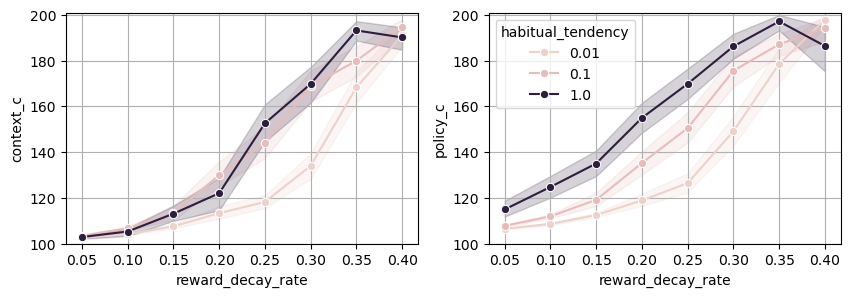

In [ ]:
df = pd.read_csv("data_reward_volatility.csv")
params = ["context_a", "context_b", "context_c", "context_d"]
params_pol = ["policy_a", "policy_b", "policy_c", "policy_d"]

# for ri, row in df[df["context_a"].isnull()].iterrows():


for ri, row in df[(df["context_c"] > 201) | (df["context_a"]  < 0.5)].iterrows():
	# print(row["context_a"])
	q_context = np.array([float(q_c) for q_c in row["q_context"].strip("[]").replace("\n","").split()])


	"""Print excluded fits context"""
	# plt.figure()
	# plt.plot(1-q_context)
	# plt.plot(q_context)
	# plt.ylim((0,1.05))

	# fi = (int(row["context_func"]))
	# x = np.arange(TAU+1)
	# y = fitting_functions[fi](np.arange(TAU+1), *row[params[fi:]])

	# plt.plot(x,y)
	# plt.title(f"nu: {row['reward_decay_rate']}, h: {row['habitual_tendency']}, rep: {row['run']}, a: {round(row['context_a'],2)}, b: {round(row['context_b'],2)}, c: {round(row['context_c'],2)}, d: {round(row['context_d'], 2)}")
	# plt.savefig(f"img\\cont_nu_{row['reward_decay_rate']}_h{row['habitual_tendency']}_rep{row['run']}.png")
	# plt.close()

for ri, row in df[(df["policy_c"] > 201) | (df["policy_a"]  < 0.3)].iterrows():

	q_action = np.array([float(q_c) for q_c in row["q_action"].strip("[]").replace("\n","").split()])

	"""Print excluded fits policy"""
	# plt.figure()
	# plt.plot(1-q_action)
	# plt.plot(q_action)
	# plt.ylim((0,1.05))

	# fi = (int(row["policy_func"]))
	# x = np.arange(TAU+1)
	# y = fitting_functions[fi](np.arange(TAU+1), *row[params[fi:]])

	# plt.plot(x,y)
	# plt.title(f"nu: {row['reward_decay_rate']}, h: {row['habitual_tendency']}, rep: {row['run']}, a: {round(row['context_a'],2)}, b: {round(row['context_b'],2)}, c: {round(row['context_c'],2)}, d: {round(row['context_d'], 2)}")
	# plt.savefig(f"img\\pol_nu_{row['reward_decay_rate']}_h{row['habitual_tendency']}_rep{row['run']}.png")
	# plt.close()

mask = ((df["context_a"]  < 0.5) | (df["context_c"] > 201))
df.loc[mask, params] = np.array([0,0,TAU+1,0])


mask = ((df["policy_a"]  < 0.3) | (df["policy_c"] > 201) )
df.loc[mask, params_pol] = np.array([0,0,TAU+1,0])

fig, axes = plt.subplots(1,2, figsize=(10,3))
for ax in axes:
	ax.grid()
	ax.set_ylim([100,201])

sns.lineplot(ax=axes[0], data=df, x="reward_decay_rate", y="context_c", hue="habitual_tendency", marker="o", legend=None)
sns.lineplot(ax=axes[1], data=df, x="reward_decay_rate", y="policy_c", hue="habitual_tendency", marker="o")


In [ ]:
df = pd.read_csv("data_reward_volatility.csv")

# df = { col : [] for col in ["run","habitual_tendency", "reward_decay_rate","trial","true_context","q_context"]}
dfs = []
for ri,row in df.iterrows():
	df_small = pd.DataFrame({},index=np.arange(TAU))
	a = np.array([float(q_c) for q_c in row["q_context"].strip("[]").replace("\n","").split()])

	df_small["q_context"] = np.array([float(q_c) for q_c in row["q_context"].strip("[]").replace("\n","").split()])#row['q_context']#np.array([float(q_c) for q_c in row["q_context"].strip("[]").replace("\n","").split()])
	df_small["q_action"] = np.array([float(q_c) for q_c in row["q_action"].strip("[]").replace("\n","").split()])
	df_small["run"] = row["run"]
	df_small["habitual_tendency"] = row["habitual_tendency"]
	df_small["reward_decay_rate"] = row["reward_decay_rate"]
	df_small["trial"] = np.arange(TAU)
	df_small["true_context"] = training_protocol[0]
	dfs.append(df_small)
df_big = pd.concat(dfs, ignore_index=True)




fig, axes = plt.subplots(3,3, figsize=(10,10))
axes = axes.flatten()
for vi, volatility in enumerate(df_big['reward_decay_rate'].unique()):
	axes[vi].grid()
	axes[vi].set_ylim((0,1.05))
	axes[vi].set_title(f"reward_volatility: {volatility}")
	sns.lineplot(ax=axes[vi], data=df_big.query(f"reward_decay_rate == {volatility}"), x="trial", y="q_context", hue="habitual_tendency", errorbar="se", palette="viridis")


fig, axes = plt.subplots(3,3, figsize=(10,10))
axes = axes.flatten()
for vi, volatility in enumerate(df_big['reward_decay_rate'].unique()):
	axes[vi].grid()
	axes[vi].set_ylim((0,1.05))
	axes[vi].set_title(f"reward_volatility: {volatility}")
	sns.lineplot(ax=axes[vi], data=df_big.query(f"reward_decay_rate == {volatility}"), x="trial", y="q_action", hue="habitual_tendency", errorbar="se", palette="viridis")


In [ ]:


# ### If I want to compare belief updates

# p["actions"] = agent.actions
# p["rewards"] = agent.rewards
# p["observations"] = agent.observations

# world2 = run_belief_update(**p)

# agent = world.agent
# post_context = agent.posterior_context
	  
			
# fig, ax = plt.subplots(1, figsize=(3,3), dpi=dpi)
# ax.set_ylim((0,1.05))
# plt.grid(axis="x", alpha=0.7)
# ax.xaxis.set_major_locator(MultipleLocator(switch))  # Set tick spacing on x-axis to 1

# for c in range(nc):
# 	ax.plot(post_context[:,1,c],label=f"Context {c+1}", linewidth=2)		         
# ax.set_title(f"Inferred context with only belief update")

In [ ]:
world.agent.dir_rew_params
world.agent.prior_policies_counts[-1,-1]

array([[1085.37544742, 1028.62455258],
       [1013.69519384, 1071.30480616]])

In [ ]:
p["actions"] = agent.actions.tolist()
p["rewards"] = agent.rewards.tolist()
p["observations"] = agent.observations.tolist()


with open("agent_behaviour.json", "w") as f:
	json.dump({k: p[k] for k in ["actions","rewards", "observations"]},f)

<Axes: >

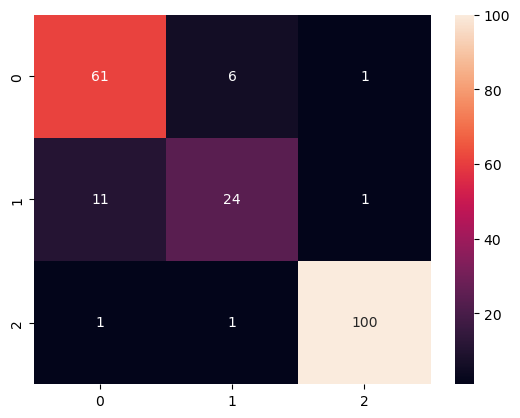

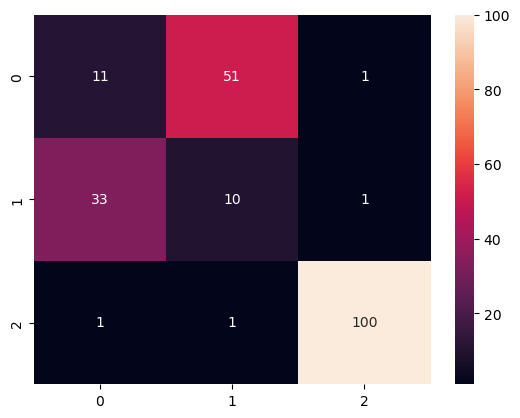

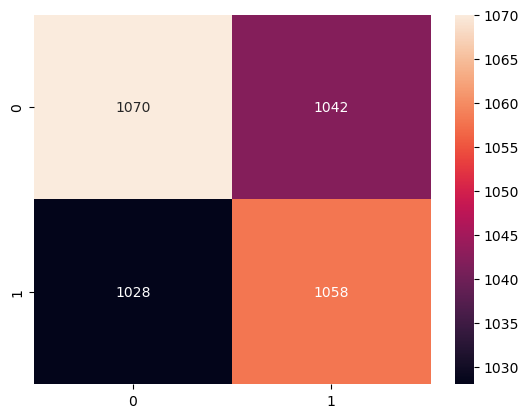

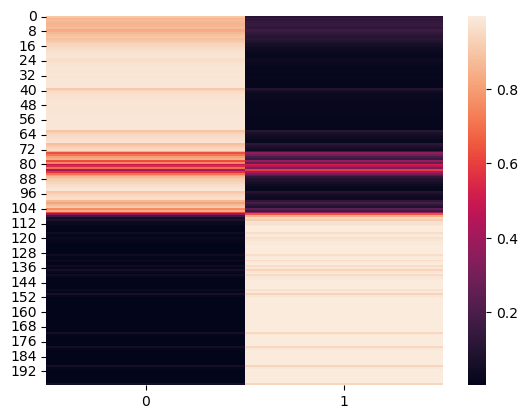

In [ ]:

plt.figure()
sns.heatmap(agent.prior_rewards_counts[-2,1,:,:,0].round(),annot=True, fmt=".0f")

plt.figure()
sns.heatmap(agent.prior_rewards_counts[-2,1,:,:,1].round(),annot=True, fmt=".0f")

plt.figure()
sns.heatmap(agent.prior_policies_counts[-2,1].round(),annot=True, fmt=".0f")

plt.figure()
sns.heatmap(agent.posterior_context[:,-1])

In [ ]:
# df = pd.read_csv(f"data_reward_slow_decay_trials{TAU}.csv")
df_big = pd.read_csv(f"new_data_reward_slow_decay_trials400.csv")
df_big_long = pd.read_csv(f"new_data_reward_slow_decay_trials400_long.csv")
params = ['context_volatility', 'utility_0', 'utility_1', 'utility_2']
all_simulations = df_big[params].drop_duplicates().sort_values(by=["context_volatility", "utility_1"], ascending=False)
simulation = all_simulations.iloc[0]


mask = np.logical_and.reduce([df_big[param] == simulation[param] for param in params])  
df = df_big[mask]
mask = np.logical_and.reduce([df_long[param] == simulation[param] for param in params])  
df_long = df_big_long[mask]


In [ ]:
"""From here I can look at individual agent behaviour and explore effects of setting certain masks."""

df = pd.read_csv("new_data_reward_slow_decay_trials400_context_volatility.csv")
df_long = pd.read_csv("new_data_reward_slow_decay_trials400_context_volatility_long.csv")
# df.rename(columns={"q_action":"q_policy"}, inplace=True)
params = ["_a", "_b", "_c", "_d"]


def show_agent_behaviour(inferred_posterior=True, action_selection=True, posterior_context_terms=False):
count = 0
print(df["habitual_tendency"].unique(),df["reward_decay_rate"].unique())

# for ri, row in df[(df["habitual_tendency"] == 0) & (df["reward_decay_rate"] == -4.962)].iterrows():
k_range = df.reward_decay_rate.unique()
# for ri, row in df[ (df["context_c"] == TAU//2 + 1) & (df["reward_decay_rate"] == k_range[0]) ].iterrows():
for ri, row in df.iterrows():
	### explore agent behaviour
	df_agent = df_long[df_long["sim"] == ri]
	df_agent["true_context"]  = np.arange(TAU).repeat(2) >= switch
	df_agent["outcome_surprise_diff"] = df_agent["outcome_surprise_c0"] - df_agent["outcome_surprise_c1"]
	df_agent["policy_surprise_diff"] = df_agent["policy_surprise_c0"] - df_agent["policy_surprise_c1"] 
	df_agent["context_prior_diff"] = np.log(df_agent["posterior_context_c0"]) - np.log(df_agent["posterior_context_c1"]) 
	df_agent["context_post_diff"] = df_agent["posterior_context_c0"] - df_agent["posterior_context_c1"] 

	df_agent["precision_prior_c0"] = 1/(df_agent["prior_pi0_c0"]*(1-df_agent["prior_pi0_c0"]))
	df_agent["precision_prior_c1"] = 1/(df_agent["prior_pi0_c1"]*(1-df_agent["prior_pi0_c1"]))
	df_agent["precision_like_c0"] = 1/(df_agent["likelihood_pi0_c0"]*(1-df_agent["likelihood_pi0_c0"]))
	df_agent["precision_like_c1"] = 1/(df_agent["likelihood_pi0_c1"]*(1-df_agent["likelihood_pi0_c1"]))
	df_agent["precision_context"] = 1/(df_agent["posterior_context_c0"]*df_agent["posterior_context_c1"])

	count += 1

	if False:

		fig, axes = plt.subplots(1,2,figsize=(10,4), sharey=True)
		for fi,fitted_posterior in enumerate(["context","policy"]):
			pars = [fitted_posterior+par for par in params]
			q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
			axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
			axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
			axes[fi].set_ylim((0,1.05))
			axes[fi].grid()
			try:
				func_ind = (int(row[f"{fitted_posterior}_func"]))
				x = np.arange(TAU+1)
				axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
				row[pars[2]] += TAU // 2
				y = fitting_functions[func_ind](np.arange(TAU+1), *row[pars[func_ind:]])
				axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
				axes[fi].legend(loc="center left")
			except:
				pass

		# ### Context terms plot
		df_agent["action"]  = df_agent["observation"]
		# # print(f'==>> df_agent[df_agent["t" == 1]]["action"].to_numpy(): {df_agent[df_agent["t"] == 1]["action"].to_numpy()}')
		# df_agent["action"] = df_agent[df_agent["t"] == 1]["action"].to_numpy().repeat(2)
		# fig, axes = plt.subplots(1,4, figsize=(20,4))
		
		# for ax in axes:
		#     ax.vlines(row["context_c"], ymin=-10, ymax=6,color="gray")
		#     ax.vlines(row["policy_c"], ymin=-10, ymax=6,color="gray", linestyle="--")

		#     ax.grid()
		#     ax.set_ylim([-10,6])
		
		# sns.scatterplot(ax = axes[0], x="tau", data = df_agent.query("t==1"),y = "outcome_surprise_diff" , hue="action", style="reward", s=20)
		# sns.scatterplot(ax = axes[1], x="tau", data = df_agent.query("t==1"),y = "policy_surprise_diff" , hue="action", style="reward", s=20)
		# sns.scatterplot(ax = axes[2], x="tau", data = df_agent.query("t==1"),y = "context_prior_diff" , hue="action", style="reward", s=20)
		# sns.scatterplot(ax = axes[3], x="tau", data = df_agent.query("t==1"),y = "context_post_diff" , hue="action", style="reward", s=20)

		# axes[-1].set_ylim([-1.2,1.2])
		# plt.suptitle("Higher difference means higher relative probability for training context")

		# # ### Policy Goal Driven Values
		# # fig,axes =plt.subplots(1,2, figsize=(6,3))
		# # plt.tight_layout()
		# # plt.subplots_adjust(hspace=0.5)

		# # for c in range(2):
		# #     axes[c].grid()
		# #     axes[c].set_ylim([0,1])
		# #     for pi in range(2):
		# #         sns.lineplot(ax=axes[c], data=df_agent.query("t==0"), x="tau",y=f"likelihood_pi{pi}_c{c}")
		# # fig.suptitle("Goal driven value of policy $L(\pi|c)$",y=1.05)


		### Action execution
		fig, axes = plt.subplots(1,3,figsize=(15,4))
		fig.tight_layout()
		sns.barplot(ax=axes[0], data=df_agent.query("t == 1"), x="true_context", y="action")
		axes[0].set_ylim((0,1))
		axes[0].set_ylabel("true context")
		axes[0].set_xlabel(f"Prevalence of degraded action, h: {row['habitual_tendency']}")

		### Policy Prior
		# plt.figure()
		sns.heatmap(ax=axes[1], data=df_agent.query("t==1")[["prior_pi0_c0", "prior_pi0_c1"]].reset_index(drop=True), vmax=1, vmin=0)
		# axes[1].set_yticklabels(np.arange(0,TAU,np.ceil(TAU/29)))
		axes[1].set_ylabel("trial")

		### Policy Precision

		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_prior_c0", label="prior pol precision c0",color="blue")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_prior_c1", label="prior pol precision c1", color="orange")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_like_c0", label="like pol precision c0", color="blue", linestyle="--")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_like_c1", label="like pol precision c1", color="orange", linestyle="--")
		axes[2].grid()# sns.scatterplot(ax=axes[2], data=df_agent.query('t==1'),x="tau",y="precision_context", label="context precision", color="black")
		axes[2].vlines(row["context_c"], ymin=axes[2].get_ylim()[0], ymax=axes[2].get_ylim()[1], color="gray")
		axes[2].vlines(row["policy_c"], ymin=axes[2].get_ylim()[0], ymax=axes[2].get_ylim()[1],color="gray", linestyle="--")



		# ### DKL between policy posterior and components
		# post_pol = df_agent[[f"posterior_pi{p}" for p in range(2)]].to_numpy()

		# for di, dist_name in enumerate(["posterior_", "likelihood_", "prior_"]):
		#         for c in range(2):
		#             dist = df_agent[[dist_name+f"pi{p}_c{c}" for p in range(2)]].to_numpy()
		#             df_agent["dkl_"+ dist_name+f"c{c}"] = (post_pol*np.log(post_pol/dist)).sum(axis=1)
					

		# fig, axes = plt.subplots(2,3, figsize=(12,6))
		# plt.tight_layout()
		# for c in range(2):
		#     for di, dist_name in enumerate(["posterior_", "likelihood_", "prior_"]):
		#         axes[c,di].grid()
		#         axes[c,di].set_ylim([0,4])
		#         axes[c,di].vlines(row["context_c"], ymin=0, ymax=4, color="gray")
		#         axes[c,di].vlines(row["policy_c"], ymin=0, ymax=4,color="gray", linestyle="--")
		#         sns.scatterplot(ax = axes[c,di], x="tau", data = df_agent.query("t==0"), y = "dkl_"+ dist_name+f"c{c}" , hue="action", s=20)

		# fig.suptitle("DKL between posterior over policies and context-specific policy posterior/likelihood/prior",y=1.03)

		# ### Rewards plot
		# fig, axes = plt.subplots(1,2)
		# plt.tight_layout()
		# sns.heatmap(ax=axes[0], data=df_agent.query("t==1")[["reward_s0_c0", "reward_s1_c0"]].reset_index(drop=True), vmax=1, vmin=0)
		# sns.heatmap(ax=axes[1], data=df_agent.query("t==1")[["reward_s0_c1", "reward_s1_c1"]].reset_index(drop=True), vmax=1, vmin=0)

		

	
	# if count>5:
	#     break




[1.    0.1   0.001] [0.007 0.02  3.   ]


0      0.090
1      0.030
2      0.000
3      0.180
4      0.280
       ...  
895    0.005
896    0.100
897    0.425
898    0.380
899    0.475
Name: preference_action_2, Length: 900, dtype: float64